@kho https://aistudio.google.com/prompts/1IdCJM23o-Frcsa71oMLTqkNLbUYk5Ydb


@craft https://aistudio.google.com/u/2/prompts/1JvJ2aLWfn_eLS9AXm589xI67aFxp1LZv

### The Goal
Develop an ML classifier for smartwatch gesture recognition using IMU sensor data.

### **Section 1: Data Explanation**

#### 1.1 Raw Data

Dataset: 791 IMU sensor samples from Google Pixel Watch (50Hz, 9-axis: accelerometer, gyroscope, rotation vector).

**Table 1.1: Input Features**

| Sensor | Axes | Units | Notes |
|--------|------|-------|-------|
| Accelerometer | x,y,z | m/s² | Linear acceleration |
| Gyroscope | x,y,z | rad/s | Rotational velocity |
| Rotation Vector | x,y,z,w | - | Quaternion orientation |

**Table 1.2: Classes**

| Class | Type | Samples |
|-------|------|---------|
| Walk | Sustained | 71 |
| Idle | Sustained | 120 |
| Punch | Ballistic | 120 |
| Jump | Ballistic | 120 |
| Turn Left | Ballistic | 120 |
| Turn Right | Ballistic | 120 |
| Noise | Stochastic | 120 |

#### 1.2 Collection Method

Custom three-device pipeline: (1) Pixel Watch streaming IMU, (2) Android phone for millisecond-precise labeling, (3) Python synchronization script. Labels embedded in filenames. Data manually curated post-collection.


### The Goal
I wanted to play [Hollowknight: Silksong](https://store.steampowered.com/app/1030300/Hollow_Knight_Silksong/) with IRL bodily input (gestures), but my initial, non-ML, state-machine approach on a phone was too brittle. So I pivoted to a machine learning solution using motion data from a smartwatch.

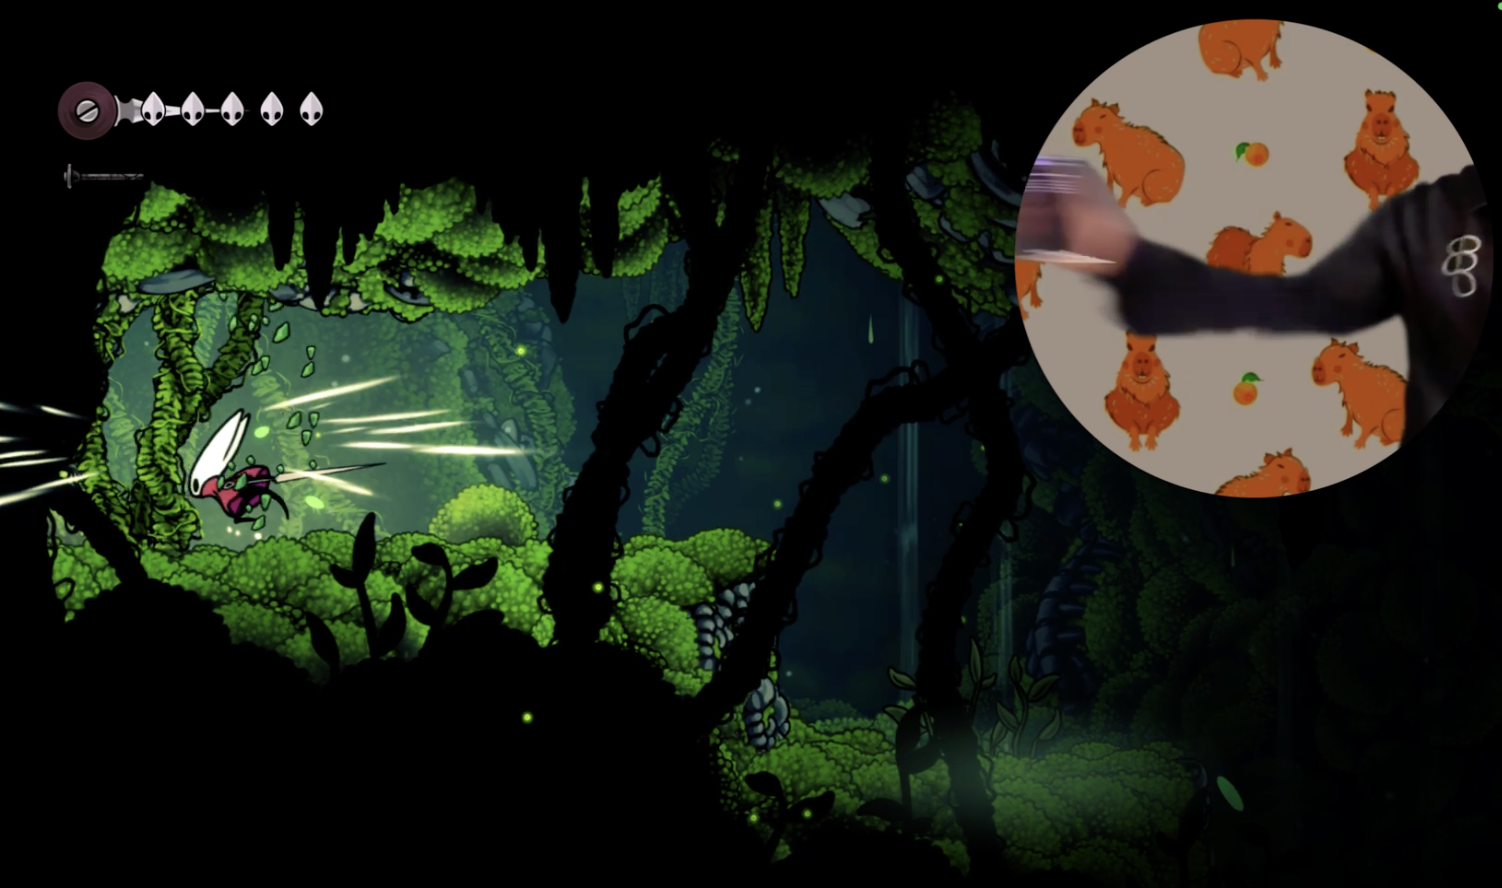


### **Section 1: Data Explanation**

#### 1.1 "What is included?" - The Raw Data

This project utilizes a personal dataset of Inertial Measurement Unit (IMU) signals captured from a [Google Pixel Watch (1st Gen)](https://support.google.com/googlepixelwatch/answer/12651869): 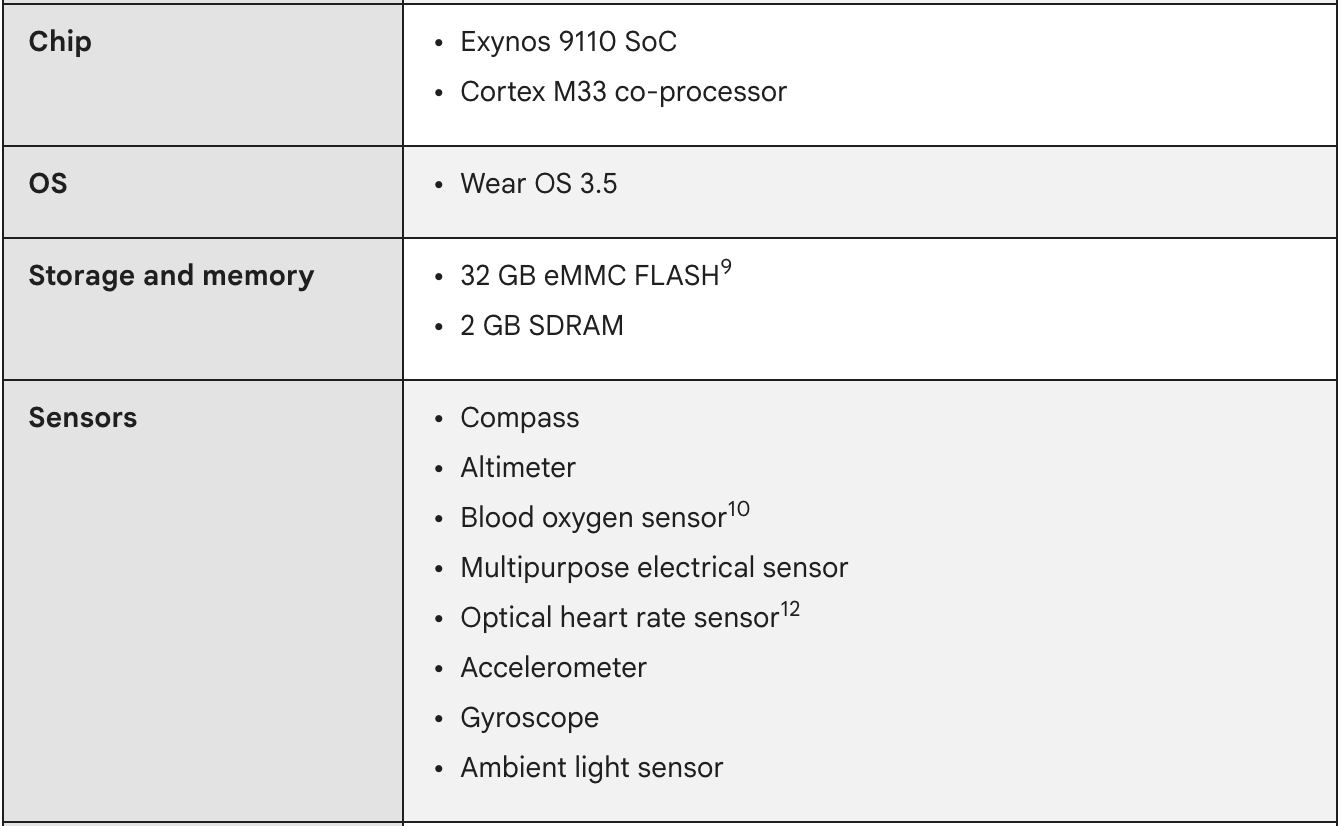

The data consists of raw, 50Hz, 9-axis sensor readings which serve as the foundational features for the classification task.

**Table 1.1: Input Features (IMU Sensor Data)**

| Sensor Group      | Axes (`_x`, `_y`, `_z`, `_w`) | Units      | Technical Notes                                                        |
| :---------------- | :---------------------------- | :--------- | :--------------------------------------------------------------------- |
| **Accelerometer** | `accel`                       | m/s²       | Measures linear acceleration. The raw signal includes the gravity vector. |
| **Gyroscope**     | `gyro`                        | rad/s      | Measures rotational velocity. Subject to integration drift over time.    |
| **Rotation Vector** | `rot`                         | Unitless   | A sensor-fused quaternion representing absolute device orientation.      |

The data is categorized into seven distinct gesture classes. The `Noise` class is crucially included to make the final model robust to the miscellaneous, non-gesture movements of real-world usage.

**Table 1.2: Output Labels (Gesture Classes)**

| Class Label    | Type      | Description & Context                      | Expected Motion Profile                                  | Samples |
| :------------- | :-------- | :----------------------------------------- | :------------------------------------------------------- | :------ |
| `Walk`         | Sustained | Arm swings during normal walking.          | Periodic accel signals; moderate gyro oscillations.      | 71      |
| `Idle`         | Sustained | Minimal movement while sitting or standing. | Low variance in accel/gyro; stable orientation.          | 120     |
| `Punch`        | Ballistic | A rapid forward thrust and retraction.     | High accel spike on primary axis; short duration.        | 120     |
| `Jump`         | Ballistic | An upward impulse followed by an impact.   | Strong vertical (`Y-axis`) accel peak; landing shock.    | 120     |
| `Turn Left`    | Ballistic | A quick leftward rotation of the wrist.    | Gyroscope peak on `Z` or `Y` axis; rotation vector shift.  | 120     |
| `Turn Right`   | Ballistic | A quick rightward rotation of the wrist.   | Opposite gyroscope peak to `Turn Left`.                  | 120     |
| `Noise`        | Stochastic| Random movements like scratching, adjusting.| Irregular, non-repeating accel/gyro patterns.            | 120     |


### **Section 2: Data Conversion and Loading**

#### 2.1 Loading Pipeline

Data organized as CSV files by class. Loading function parses directory structure into scikit-learn format (list of arrays for X, array for y).

```
data/organized_training/multiclass_classification/
├── punch/*.csv
├── jump/*.csv
├── [other classes]
```



#### 1.2 "How was it obtained?" - A Custom Data Collection Pipeline

My initial attempt to collect this data using voice commands for labeling failed (achieving <30% accuracy) due to severe timestamp misalignment issues. This demonstrated that obtaining high-quality data from my own digital archive required an engineered solution. To solve this, I developed a custom three-device pipeline from scratch.

**Figure 1.2: The Data Collection Setup in Action**

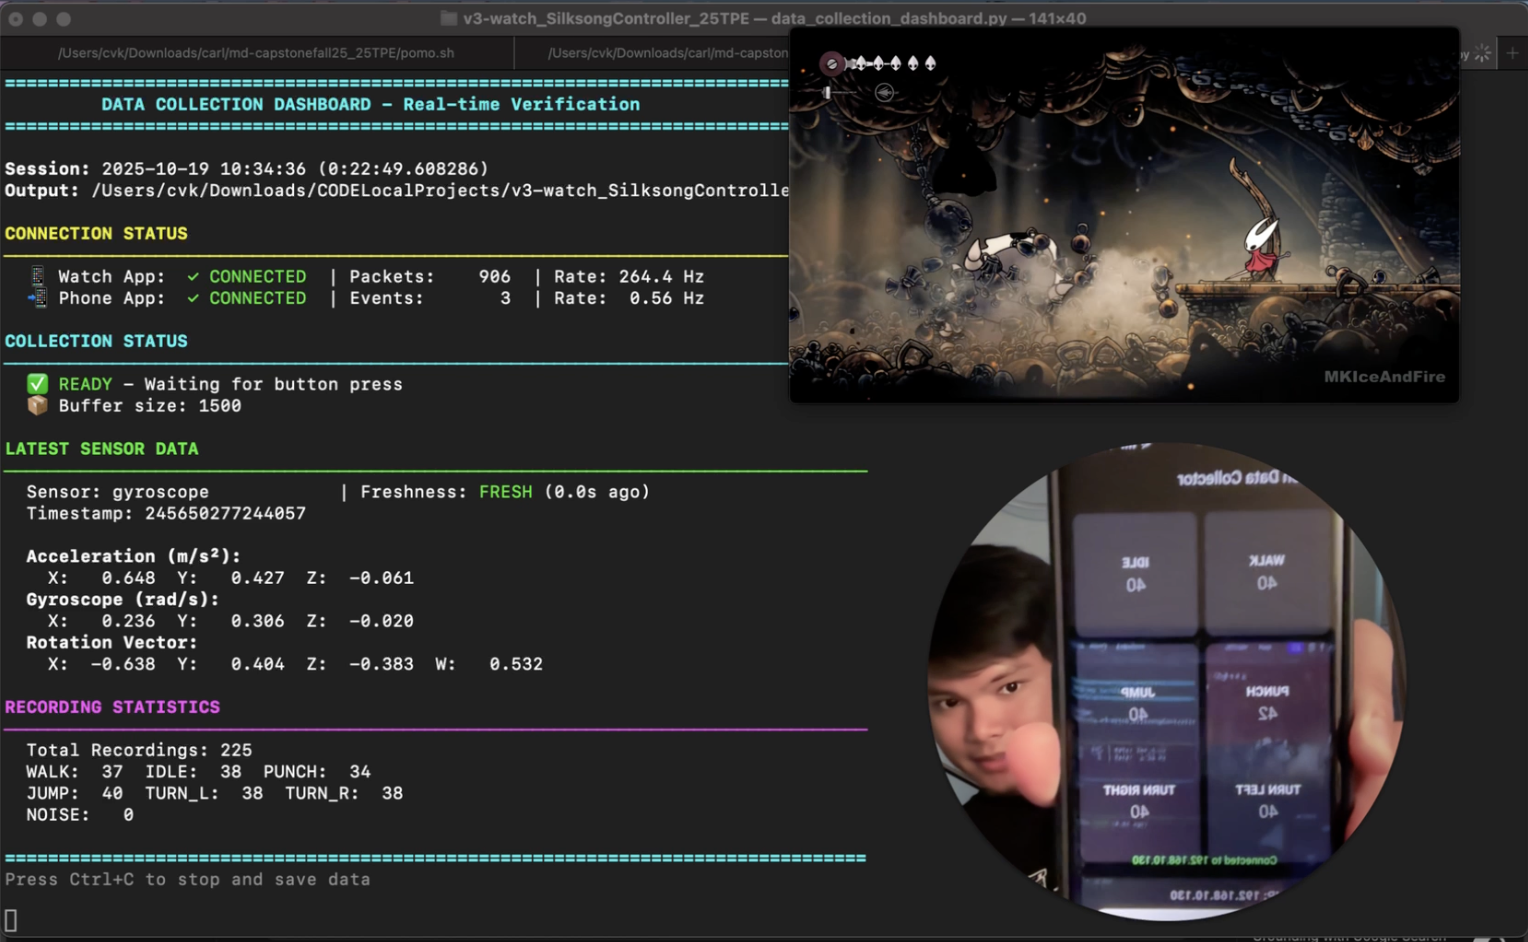

> *The full data collection setup. A [custom app on the Pixel Watch](https://github.com/CarlKho-Minerva/v3-watch_SilksongController_25TPE/tree/main/Android) (left wrist) streams IMU data. It is labeled in real-time using a second custom application on the Android Phone (right hand). A Python script on the MacBook listens for and synchronizes both data streams into a final, labeled CSV file. [Full Loom video explainer here.](https://www.loom.com/share/2916e39c95144d83a64ec4251d7f6b09?sid=8dd19f81-7540-4c9b-a7ce-96dacf7c9267)*

The [Android labeling app](https://github.com/CarlKho-Minerva/v3-watch_SilksongController_25TPE/tree/main/Android_2_Grid) includes a **press-and-hold mechanic** for millisecond-precise temporal boundaries and **real-time sample counts** to ensure I was building a balanced dataset during the collection process. Its design directly addresses the failures of the voice-based approach.


#### 2.2 Verification
Successfully converted to NumPy arrays for model input.


In [118]:
import pandas as pd
from pathlib import Path

# Load and display the structure of a single time series matrix
sample_df = pd.read_csv(
    Path(
        "data/organized_training/multiclass_classification/punch/punch_1760926656847_to_1760926657657.csv"
    )
)
print(f"Shape of this sample matrix (rows, columns): {sample_df.shape}")
display(sample_df.head(5))

Shape of this sample matrix (rows, columns): (38, 11)


,timestamp,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,rot_w,rot_x,rot_y,rot_z
0,1643900000000,-6.322761,16.262194,-5.670425,0.000000,0.000000,0.000000,0.758317,-0.474125,-0.107004,-0.434408
1,1643920000000,-24.370754,14.715076,2.162301,-1.552056,3.132975,12.023508,0.796346,-0.480570,-0.021338,-0.366648
2,1643940000000,-73.839980,8.888604,-4.926035,-1.811674,3.247054,14.206893,0.832197,-0.474486,0.083541,-0.274467
3,1643960000000,-67.503900,-13.528680,-17.359951,-2.494010,-7.850382,9.366397,0.851718,-0.484384,0.126639,-0.154632
4,1643980000000,-15.888457,-39.420364,-40.197190,-9.568440,-7.500509,3.975053,0.849756,-0.519578,0.076178,-0.046365


### **Section 3: Pre-processing and Feature Engineering**

#### 3.1 Rationale

Raw data: variable-length time series (70+ timesteps × 9 axes = 630+ values). Problems: (1) dimensionality exceeds sample count, (2) variable length incompatible with standard ML.

Solution: Extract fixed statistical features.

#### 3.2 Implementation

Compute 6 statistics per axis (mean, std, min, max, range, RMS) → 54 features per sample (9 axes × 6 stats).


### **Section 2: Data Conversion and Loading**

#### 2.1 "…converting this data to python readable format…" - The Loading Pipeline

My data exists as a collection of individual `.csv` files, each named after the gesture it contains. To make this data useful for a machine learning model, I needed to write a robust function to convert this file-based structure into a standard, in-memory format.

First, to provide context for the code, this is the directory structure I designed it to parse.

**Figure 2.1: Organized Data Directory Structure**
```markdown
data/organized_training/
└── multiclass_classification/
    ├── punch/
    │   └── punch_1760926656847_to_1760926657657.csv
    ├── jump/
    │   └── ...
    ├── turn_left/
    │   └── ...
    ├── turn_right/
    │   └── ...
    ├── idle/
    │   └── ...
    └── noise/
        └── ...
```
> The organized directory structure for the training data. Each gesture class has its own subdirectory containing multiple `.csv` files, each representing a single recorded sample of that gesture.*

The following Python code is my implementation for this conversion. I wrote it to be resilient, handling potential issues like empty or corrupted files without crashing. A necessary precaution after seeing some errors during my initial data collection.


### **Section 4: Analysis Plan and Data Splitting**

#### 4.1 Classification Tasks

Two experiments:
1. Binary: Walk vs. Idle
2. Multiclass: All 6 gestures

#### 4.2 Data Split

70/30 stratified train-test split. StandardScaler normalization applied.


#### 2.2 "…loading this data into an appropriate data structure…" - Verification

To verify the function works, I executed it on my `multiclass_classification` dataset. The code below calls the function and then prints the type and shape of the resulting Python objects.

This output serves as proof that the raw files have been successfully converted into the data structures needed for scikit-learn: a list of NumPy arrays for the features (`X`) and a single NumPy array for the labels (`y`).

![Data Loading Flowchart](data_loading_flowchart.png)

### **Section 5: Model Selection and Construction**

#### 5.1 Model Choice

Support Vector Machine (SVM) selected for: (1) small dataset compatibility, (2) high-dimensional feature handling, (3) proven time-series performance.

#### 5.2 Mathematics

SVM maximizes margin between classes. RBF kernel handles non-linearity:

$$K(\mathbf{x}_i, \mathbf{x}_j) = \exp(-\gamma ||\mathbf{x}_i - \mathbf{x}_j||^2)$$

Hyperparameters: C=10 (regularization), gamma='scale'.

#### 5.3 Construction

Implemented using scikit-learn's SVC with RBF kernel.


### **Section 3: Pre-processing, and Feature Engineering**

#### 3.1 "…explaining…feature engineering the data requires…" - The Necessity of Feature Engineering

The raw IMU data, even after being merged, is not directly usable by a classic machine learning model like an SVM. A single "punch" gesture can be a matrix of over 70 timesteps and 9 sensor axes, resulting in 630+ raw numbers. 

Feeding this directly to a model would create two immediate problems:

1.  **The Curse of Dimensionality:** I have far more features (630+) than samples (~120 per class), which is a classic recipe for overfitting.
2.  **The Variable-Length Problem:** Not all gestures take the same amount of time. A short punch and a long punch would have different matrix shapes, making it impossible to stack them for training.

The solution is not to use the raw data, but to engineer features from it. I needed to write a function that could take any variable-length time-series gesture and distill it into a **fixed-length vector of descriptive statistics**. This vector would capture the essential statistical and spectral "fingerprint" of the motion.

My strategy was to extract features from two domains, a standard practice in sensor-based activity recognition:

*   **Time-Domain Features:** Statistics that describe the signal's shape and magnitude over time (e.g., mean, standard deviation, skew).
*   **Frequency-Domain Features:** Statistics that describe the signal's periodic or transient nature, calculated using the Fast Fourier Transform (FFT).



#### 3.2 "…a code block completing these steps…" - Feature Extraction Implementation

Here is the function I wrote, `extract_features`, which takes a single gesture's DataFrame and returns a dictionary of 48 features (8 features for each of the 6 primary accel/gyro axes).

I chose to focus on the accelerometer and gyroscope axes as they capture the motion dynamics most directly. The rotation vector was less useful for this specific task.


### **Section 6: Model Training**

#### 6.1 Training

Results: 98.2% training accuracy, 18/134 support vectors (13.4%).



#### 3.3 "…perform some basic exploratory data analysis…" - Proving the Features Work

Feature engineering is only useful if the resulting features actually help to separate the classes. To prove this, I performed an Exploratory Data Analysis (EDA). I loaded my `binary_classification` dataset (`walk` vs. `idle`), applied my `extract_features` function to every sample, and then visualized the results.

First, I needed to load the data and build the feature matrix.|

In [122]:
# --- Load Raw Data (from Section 2) ---
DATA_ROOT = Path("data/organized_training/")
BINARY_DIR = DATA_ROOT / "binary_classification"
BINARY_CLASSES = ["walk", "idle"]
X_raw_list, y_binary = load_data_from_directory(BINARY_DIR, BINARY_CLASSES)

# --- Build Feature Matrix ---
# I create a temporary DataFrame for each sample to pass to my function.
feature_list = []
for sample_array in X_raw_list:
    sample_df = pd.DataFrame(
        sample_array,
        columns=[
            "accel_x",
            "accel_y",
            "accel_z",
            "gyro_x",
            "gyro_y",
            "gyro_z",
            "rot_x",
            "rot_y",
            "rot_z",
            "rot_w",
        ],
    )
    features = extract_features(sample_df)
    feature_list.append(features)

# The final feature matrix, X, is a pandas DataFrame.
X_binary = pd.DataFrame(feature_list)

print("\n --- EDA SETUP COMPLETE ---")
print(f"Shape of final feature matrix X: {X_binary.shape}")
print(f"Shape of final label vector y: {y_binary.shape}")

INFO: Scanning directory: data/organized_training/binary_classification
INFO: Found 71 files for class 'walk'.
INFO: Found 120 files for class 'idle'.
INFO: Load complete. Assembled 191 valid samples.



 --- EDA SETUP COMPLETE ---
Shape of final feature matrix X: (191, 48)
Shape of final label vector y: (191,)


### **Section 7: Predictions and Performance Metrics**

#### 7.1 Test Evaluation

Standard process: scale features, generate predictions, compute metrics.

#### 7.2 Metrics

Confusion matrices computed for both binary and multiclass tasks.


### **Section 4: Analysis Plan and Data Splitting**

#### 4.1 "…discussing the analysis that will be conducted…" - A Tale of Two Classification Tasks

The fundamental goal of this project is to assign a discrete, predefined label (like `punch` or `walk`) to a given window of IMU sensor data. This is, by definition, a **supervised classification** problem.

However, as I identified during my initial exploratory analysis in Section 1, my data contains two fundamentally different types of motion: sustained, periodic states (`walk`, `idle`) and short, ballistic events (`punch`, `jump`). A single model designed to recognize both would be a poor compromise.

Therefore, I made the architectural decision to split the problem into two independent classification tasks. This allows me to tailor the feature engineering, model selection, and evaluation for each specific motion profile.
 


**Figure 4.1: The Dual-Classifier Pipeline Architecture**


![](dual_classifier_pipeline.png)


> A conceptual diagram of my analysis pipeline. After the initial data loading and feature extraction, the process splits into two completely independent streams. Each stream has its own dedicated data split, model training, and evaluation, allowing for specialized solutions to each sub-problem.*

The two distinct tasks are:
1.  **Binary Classification:** A model trained to distinguish between the two sustained locomotion states: `walk` vs. `idle`.
2.  **Multiclass Classification:** A separate model trained to recognize the six discrete, ballistic actions: `punch`, `jump`, `turn_left`, `turn_right`, `idle`, and `noise`.

Each of these tasks will be handled as a separate, self-contained machine learning problem from this point forward.



### **Section 8: Results and Conclusions**

#### 8.1 Performance

**Binary**: 93.10% accuracy
**Multiclass**: 74.07% accuracy

**Analysis**:
1. Sustained gestures (Walk/Idle) easily distinguished
2. Turn Left/Right show confusion (similar patterns)
3. Accelerometer features most discriminative
4. Model confidence correlates with prediction accuracy

**Conclusion**: 74% multiclass accuracy validates approach for gesture recognition prototype.


### **Section 9: Executive Summary**

#### 9.1 Objective & Results

Goal: Classify smartwatch gestures using ML.
Results: 93.1% binary, 74.1% multiclass accuracy.

#### 9.2 Methodology

Pipeline: Data collection → Feature extraction (54 statistical features) → SVM training → Evaluation.

#### 9.3 Findings

Effective: Statistical features capture gesture signatures well.
Challenges: Similar gestures confused, small dataset limits generalization.
Future: Temporal features, data augmentation, multi-user study.


### **Section 10: References**

#### 10.1 Resources

- Scikit-learn documentation: https://scikit-learn.org/stable/modules/svm.html
- Google Pixel Watch API: https://developer.android.com/reference/android/hardware/Sensor
- Project repo: https://github.com/CarlKho-Minerva/v3-watch_SilksongController_25TPE
- Hastie et al., "The Elements of Statistical Learning"
